In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

import logomaker

Fontconfig warning: ignoring UTF-8: not a valid region tag
Matplotlib is building the font cache; this may take a moment.


In [461]:
library = pd.read_csv('../../source_data/02_library/CDK_library_final.csv')


#-----load single amino-acid variants (SAVs) breakdown for each subpool------
SAV_ABE1 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool1.zip')
SAV_ABE1 = pd.merge(SAV_ABE1, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE1 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool1.zip')
SAV_CBE1 = pd.merge(SAV_CBE1, library[['gRNA_id', 'Gene']], on='gRNA_id')


SAV_ABE2 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool2.zip')
SAV_ABE2 = pd.merge(SAV_ABE2, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE2 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool2.zip')
SAV_CBE2 = pd.merge(SAV_CBE2, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_ABE3 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool3.zip')
SAV_ABE3 = pd.merge(SAV_ABE3, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE3 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool3.zip')
SAV_CBE3 = pd.merge(SAV_CBE3, library[['gRNA_id', 'Gene']], on='gRNA_id')

#------also load the raw editing for each (i.e. with compound mutations) -------

ABE1 = pd.read_csv('../../screening_data/04_editing/ABE_subpool1_HGVSp.zip')
CBE1 = pd.read_csv('../../screening_data/04_editing/CBE_subpool1_HGVSp.zip')
ABE2 = pd.read_csv('../../screening_data/04_editing/ABE_CDK12_13_HGVSp.zip')
CBE2 = pd.read_csv('../../screening_data/04_editing/CBE_CDK12_13_HGVSp.zip')
ABE3 = pd.read_csv('../../screening_data/04_editing/ABE_CDK2_4_6_HGVSp.zip')
CBE3 = pd.read_csv('../../screening_data/04_editing/CBE_CDK2_4_6_HGVSp.zip')

In [48]:
np.unique(SAV_ABE1['gRNA_id'])

array(['gRNA_CDK19_targ_6273', 'gRNA_CDK19_targ_6274',
       'gRNA_CDK19_targ_6275', ..., 'gRNA_CDK9_targ_1737',
       'gRNA_CDK9_targ_1738', 'gRNA_CDK9_targ_1739'], dtype=object)

In [462]:
import re

def extract_numbers(text):
    """Extracts all numbers from the given text."""
    return [int(i) for i in re.findall(r'\d+', text)][0]



def logo_df_maker(merge, gRNA_id, context_size, min_perc):

    gene = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]

    cdks = pd.read_csv('../../source_data/01_library_generation_files/cdks_info_updated.csv')

    cdk_prot = cdks.loc[cdks['Gene']==gene, 'Protein'].values[0]

    d4 = merge[(merge['HGVSp']!='WT') & (merge['%Reads']>=min_perc) & (merge['gRNA_id']==gRNA_id)]
    
    codons = []
    refs = []
    alts = []
    for i, val in d4.iterrows():
        h = val['HGVSp']
        c = val['%Reads']

        codon = extract_numbers(h)
        ref = h[0]
        alt = h[-1]
        codons.append(codon)
        refs.append(ref)
        alts.append(alt)

    d4['codon'] = codons
    d4['ref'] = refs
    d4['alt'] = alts

    min_cod = min(d4['codon'])
    max_cod = max(d4['codon'])

    assert cdk_prot[min_cod-1] == d4.loc[d4['codon']==min_cod, 'ref'].values[0]
    assert cdk_prot[max_cod-1] == d4.loc[d4['codon']==max_cod, 'ref'].values[0]

    start_cod = max(min_cod-context_size, 0)
    end_cod = min(max_cod +context_size, len(cdk_prot))

    codon_options = np.unique([i for i in cdk_prot[start_cod-1: end_cod]] + refs + alts)

    sequence = cdk_prot[start_cod-1: end_cod]
    seq_length = len(sequence)

    zero_array = [list(range(start_cod, end_cod+1))] + [np.zeros(seq_length) for i in range(len(codon_options))]

    logo_df = pd.DataFrame(dict(zip(['codon'] + list(codon_options), zero_array)))

    for i, val in d4.iterrows():
        cod = val['codon']
        alt = val['alt']
        perc = val['%Reads']

        logo_df.loc[logo_df['codon']==cod, alt]+=perc

    for i, val in enumerate(list(range(start_cod, end_cod+1))):
        cod = val
        aa = sequence[i]

        remaining_prob = 100 - np.sum(logo_df[logo_df['codon']==cod][codon_options].values)

        logo_df.loc[logo_df['codon']==cod, aa]+=remaining_prob

    logo_df = logo_df.set_index('codon')

    return logo_df, min_cod, max_cod, d4, sequence

In [58]:
gene = merge.loc[merge['gRNA_id']=='gRNA_id', 'Gene']
gene

Series([], Name: Gene, dtype: object)

In [463]:
def logo_plotter(gRNA_id, logo_df, ABE1, d4, min_perc):
    
    fig, ax = plt.subplots(figsize=(8,2))
    ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax)
    ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=12)
    ss_logo.ax.set_yticks([0,25, 50, 75,100])
    ss_logo.ax.set_yticklabels([0,25, 50, 75,100], fontsize=12);
    ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
    ss_logo.ax.set_ylabel('Probability', fontsize=14)

    ss_logo.ax.get_xticks()

    d_nonzero = d4[d4['%Reads']>0]


    for i, val in d_nonzero.iterrows():
        alt = val['alt']
        loc = val['codon']
        pp = val['%Reads']
        ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

    ss_logo.style_spines(spines=['left', 'right', 'top'], visible=False)

    subset = ABE1[(ABE1['gRNA_id']==gRNA_id) & (ABE1['HGVSp']!='WT') & (ABE1['%Reads']>=min_perc)]

    s2 = ''
    for i, val in subset[:5].iterrows():
        pp = val['%Reads']
        s2 += f"{val['HGVSp']}, {np.round(pp,1)}%, "


    ss_logo.ax.set_title(f'{s2}', fontsize=14)

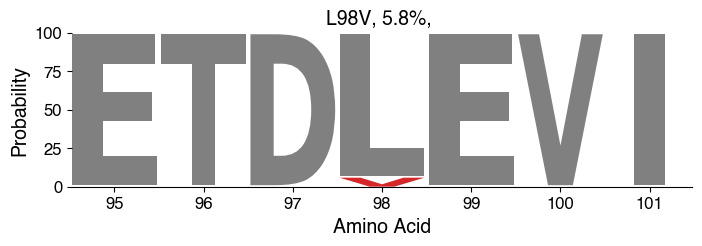

In [299]:
merge = SAV_CBE1
gRNA_id = 'gRNA_CDK7_targ_70'
context_size=3
min_perc = 2

logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

logo_plotter(gRNA_id, logo_df, CBE1, d4, min_perc=2)

In [300]:
CBE1[CBE1['gRNA_id']==gRNA_id]

,gRNA_id,HGVSp,#Reads,%Reads
330769,gRNA_CDK7_targ_70,WT,61005,91.452171
330770,gRNA_CDK7_targ_70,L98V,3879,5.814982
330771,gRNA_CDK7_targ_70,L98I,268,0.401757
330772,gRNA_CDK7_targ_70,M94V,175,0.262341
330773,gRNA_CDK7_targ_70,E99*,154,0.230860
...,...,...,...,...
330882,gRNA_CDK7_targ_70,T96N_E99Q,1,0.001499
330883,gRNA_CDK7_targ_70,T96N_L98I,1,0.001499
330884,gRNA_CDK7_targ_70,T96N_L98R,1,0.001499
330885,gRNA_CDK7_targ_70,T96N_L98R_E99G,1,0.001499


In [ ]:
min_edit = 60
a = list(np.unique(SAV_CBE1[(SAV_CBE1['Gene']=='CDK9') & (SAV_CBE1['HGVSp']!='WT') & (SAV_CBE1['%Reads']>=min_edit)]['Codon']))

In [323]:
d = []
for min_edit in range(1,100):

    a = list(np.unique(SAV_CBE1[(SAV_CBE1['Gene']=='CDK9') & (SAV_CBE1['HGVSp']!='WT') & (SAV_CBE1['%Reads']>=min_edit)]['Codon']))
    b = list(np.unique(SAV_ABE1[(SAV_ABE1['Gene']=='CDK9') & (SAV_ABE1['HGVSp']!='WT') & (SAV_ABE1['%Reads']>=min_edit)]['Codon']))

    c = len(np.unique(a+b))
    d.append(c/372)
    print(f'{min_edit} {c/372}')

1 1.0
2 0.9973118279569892
3 0.9946236559139785
4 0.9946236559139785
5 0.9946236559139785
6 0.9946236559139785
7 0.9946236559139785
8 0.9919354838709677
9 0.9919354838709677
10 0.9865591397849462
11 0.9865591397849462
12 0.9865591397849462
13 0.9838709677419355
14 0.9758064516129032
15 0.9704301075268817
16 0.9704301075268817
17 0.9704301075268817
18 0.9623655913978495
19 0.9596774193548387
20 0.956989247311828
21 0.9489247311827957
22 0.946236559139785
23 0.946236559139785
24 0.9408602150537635
25 0.9381720430107527
26 0.9354838709677419
27 0.9354838709677419
28 0.9274193548387096
29 0.9220430107526881
30 0.9139784946236559
31 0.9139784946236559
32 0.9086021505376344
33 0.9086021505376344
34 0.9059139784946236
35 0.9032258064516129
36 0.9005376344086021
37 0.8951612903225806
38 0.8951612903225806
39 0.8924731182795699
40 0.8870967741935484
41 0.8790322580645161
42 0.8736559139784946
43 0.8682795698924731
44 0.8548387096774194
45 0.8548387096774194
46 0.8467741935483871
47 0.8413978494

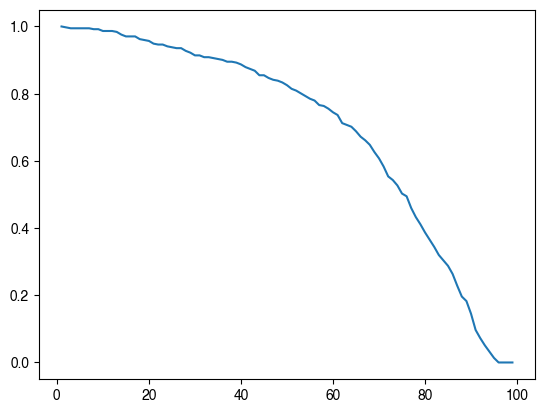

In [324]:
plt.plot(range(1,100), d)

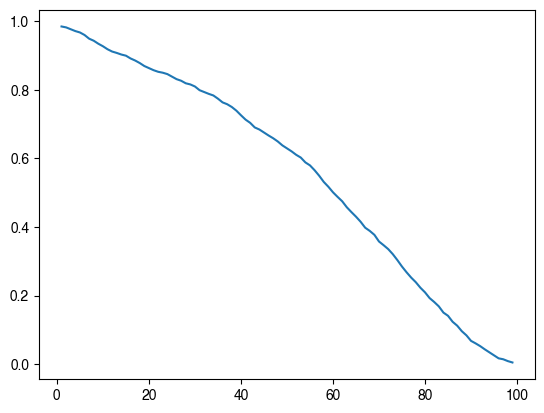

In [329]:
plt.plot(range(1,100), d)

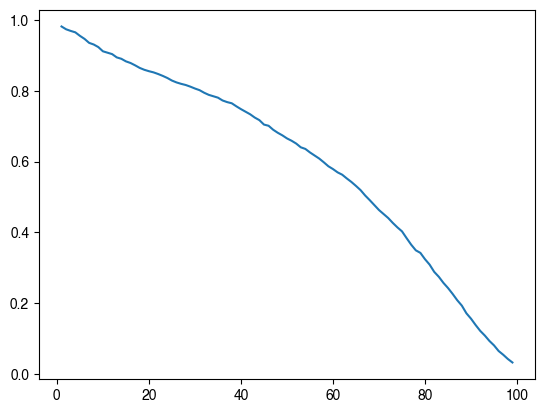

In [331]:
plt.plot(range(1,100), d)

In [330]:
d = []
g = 'CDK13'
for min_edit in range(1,100):

    a = list(np.unique(SAV_CBE2[(SAV_CBE2['Gene']==g) & (SAV_CBE2['HGVSp']!='WT') & (SAV_CBE2['%Reads']>=min_edit)]['Codon']))
    b = list(np.unique(SAV_ABE2[(SAV_ABE2['Gene']==g) & (SAV_ABE2['HGVSp']!='WT') & (SAV_ABE2['%Reads']>=min_edit)]['Codon']))

    c = len(np.unique(a+b))
    d.append(c/1512)
    print(f'{min_edit} {c/1512} {c}')

1 0.9814814814814815 1484
2 0.9735449735449735 1472
3 0.968915343915344 1465
4 0.96494708994709 1459
5 0.955026455026455 1444
6 0.9464285714285714 1431
7 0.9351851851851852 1414
8 0.9305555555555556 1407
9 0.9232804232804233 1396
10 0.9113756613756614 1378
11 0.9074074074074074 1372
12 0.9034391534391535 1366
13 0.8941798941798942 1352
14 0.8902116402116402 1346
15 0.8829365079365079 1335
16 0.8783068783068783 1328
17 0.8716931216931217 1318
18 0.8644179894179894 1307
19 0.8591269841269841 1299
20 0.8551587301587301 1293
21 0.8518518518518519 1288
22 0.8472222222222222 1281
23 0.841931216931217 1273
24 0.8359788359788359 1264
25 0.8287037037037037 1253
26 0.8234126984126984 1245
27 0.8194444444444444 1239
28 0.8161375661375662 1234
29 0.8115079365079365 1227
30 0.8062169312169312 1219
31 0.8015873015873016 1212
32 0.7943121693121693 1201
33 0.7883597883597884 1192
34 0.7843915343915344 1186
35 0.7804232804232805 1180
36 0.7724867724867724 1168
37 0.7678571428571429 1161
38 0.7645502645

In [301]:
#ISSUE HERE!!! -- NEED TO FIX!!! (COULD AFFECT MUTATION ANALYSIS AS WELL!!!)

SAV_CBE1[SAV_CBE1['gRNA_id']==gRNA_id]

,HGVSp,#Reads,%Reads,gRNA_id,Codon,Gene
84991,WT,61005,91.452171,gRNA_CDK7_targ_70,WT,CDK7
84992,L98V,3952,5.924416,gRNA_CDK7_targ_70,98,CDK7
84993,L98I,281,0.421245,gRNA_CDK7_targ_70,98,CDK7
84994,M94V,184,0.275833,gRNA_CDK7_targ_70,94,CDK7
84995,E99*,180,0.269837,gRNA_CDK7_targ_70,99,CDK7
84996,M94I,162,0.242853,gRNA_CDK7_targ_70,94,CDK7
84997,T96N,140,0.209873,gRNA_CDK7_targ_70,96,CDK7
84998,E95*,132,0.197880,gRNA_CDK7_targ_70,95,CDK7
84999,D97Y,131,0.196381,gRNA_CDK7_targ_70,97,CDK7
85000,D97E,60,0.089946,gRNA_CDK7_targ_70,97,CDK7


# ALSO MAKE A DNA VERSION

# Combined plots

In [335]:
data = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_ABE_barcode_DMSO_base.csv')

condition = 'HQ461'
FDR_cutoff = 0.1

all_conditions = ['BSJ-4-116', 'CDK12-IN-2', 'HQ461']

if (f'LFC_median_ABE_{condition}' in data.columns) or (f'LFC_median_CBE_{condition}' in data.columns):
    try:
        subset = data[(data[f'FDR_ABE_{condition}']<FDR_cutoff)  & (data['classification']=='targeting')].sort_values(by=f'LFC_median_ABE_{condition}', ascending=False)
    except:
        subset = data[(data[f'FDR_CBE_{condition}']<FDR_cutoff)  & (data['classification']=='targeting')].sort_values(by=f'LFC_median_CBE_{condition}', ascending=False)
else:
    subset = data[(data[f'FDR_{condition}']<FDR_cutoff) & (data['classification']=='targeting')].sort_values(by=f'LFC_median_{condition}', ascending=False)

subset[:10]

,gRNA_id,Gene,classification,ABE_BSJ-4-116_REP1,ABE_BSJ-4-116_REP2,ABE_BSJ-4-116_REP3,LFC_avg_ABE_BSJ-4-116,LFC_median_ABE_BSJ-4-116,base_RPM,base_RAW,...,p_ABE_BSJ-4-116,FDR_ABE_BSJ-4-116,p_ABE_CDK12-IN-2,FDR_ABE_CDK12-IN-2,p_ABE_HQ461,FDR_ABE_HQ461,p_ABE_T0,FDR_ABE_T0,p_Plasmid,FDR_Plasmid
492,gRNA_CDK12_targ_2232,CDK12,targeting,6.125533,6.335788,7.184101,6.548474,6.335788,73.276138,3369.0,...,4.102532e-10,6.657042e-07,4.102532e-10,0.000002,4.102532e-10,9.985563e-07,0.001166,0.709679,0.487851,0.883638
498,gRNA_CDK12_targ_2238,CDK12,targeting,0.386960,0.288864,0.312813,0.329546,0.312813,29.924039,563.0,...,4.539473e-01,9.999790e-01,5.624222e-01,0.999968,4.102532e-10,9.985563e-07,0.298840,0.965181,0.048795,0.535150
1652,gRNA_CDK12_targ_3392,CDK12,targeting,1.827192,1.586179,1.481560,1.631643,1.586179,25.178391,515.0,...,4.938928e-03,2.968235e-01,1.348968e-01,0.845344,3.278968e-06,3.990504e-03,0.031940,0.778828,0.143586,0.744382
493,gRNA_CDK12_targ_2233,CDK12,targeting,3.445245,3.149981,4.093716,3.562981,3.445245,57.824745,1889.0,...,1.374784e-07,1.338490e-04,2.030506e-04,0.032948,3.278968e-06,3.990504e-03,0.106939,0.874434,0.334267,0.976582
2134,gRNA_CDK12_targ_3874,CDK12,targeting,3.677316,1.005323,1.080880,1.921173,1.080880,63.557104,1504.0,...,2.148977e-03,1.902040e-01,1.557018e-03,0.106754,1.101050e-04,7.657018e-02,0.135763,0.999936,0.409859,0.929734
2864,gRNA_CDK13_targ_4604,CDK13,targeting,4.873180,4.681693,5.298524,4.951133,4.873180,96.766262,4449.0,...,4.102532e-10,6.657042e-07,1.212372e-06,0.001798,4.680600e-05,4.557032e-02,0.121815,0.893562,0.417758,0.814436
4175,gRNA_CDK13_targ_5915,CDK13,targeting,1.754021,1.863316,3.347764,2.321700,1.863316,3.960097,81.0,...,1.756383e-04,4.071463e-02,1.216686e-04,0.021153,1.280242e-04,7.790275e-02,0.075923,0.916376,0.027697,0.528026
1984,gRNA_CDK12_targ_3724,CDK12,targeting,1.906717,0.113763,0.535558,0.852013,0.535558,152.142056,5258.0,...,7.339671e-02,8.029105e-01,3.040691e-01,0.999968,8.337541e-05,6.764525e-02,0.464434,0.894619,0.392861,0.814436
958,gRNA_CDK12_targ_2698,CDK12,targeting,-1.303115,1.372121,-0.898326,-0.276440,-0.898326,101.539400,2969.0,...,1.231921e-01,7.718138e-01,2.010582e-01,0.999968,2.129132e-05,9.689918e-02,0.121787,0.855563,0.032897,0.446710
1103,gRNA_CDK12_targ_2843,CDK12,targeting,-1.023859,-0.314829,-3.545491,-1.628060,-1.023859,63.706087,1526.0,...,4.140721e-03,5.690567e-01,2.809328e-01,0.999968,3.981067e-05,9.689918e-02,0.016324,0.778828,0.375462,0.814436


In [336]:
topx = subset[:10]

conditions = ['HQ461', 'BSJ-4-116', 'CDK12-IN-2']
true_name = ['HQ461', 'BSJ-4-116', 'CDK12-IN-2']
condition_dict = dict(zip(conditions, true_name))

condition = []
replicate = []
lfc = []
g_id = []
names = []

for i, val in topx.iterrows():

    g = val['gRNA_id']
    #nn = val['Gene'] + ' ' + val['Top_HGVSp'] #+ f'\n({val["gRNA_id"]})'

    for drug in conditions:
        d = condition_dict[drug]

        for rep in range(1,4):

            if (f'ABE_{drug}_REP{rep}' in topx.columns) or (f'CBE_{drug}_REP{rep}' in topx.columns):
                try:
                    r = f'ABE_{drug}_REP{rep}'
                    l = val[r]
                except:
                    r = f'CBE_{drug}_REP{rep}'
                    l = val[r]


            lfc.append(l)
            condition.append(d)
            replicate.append(rep)
            g_id.append(g)
            #names.append(nn)

plot_df = pd.DataFrame(dict(zip(['gRNA_id',  'Replicate', 'LFC', 'Condition'], [g_id, replicate, lfc, condition]))).sort_values(by='LFC', ascending=False)

In [350]:
plot_df

,gRNA_id,Replicate,LFC,Condition
2,gRNA_CDK12_targ_2232,3,7.399880,HQ461
1,gRNA_CDK12_targ_2232,2,7.317829,HQ461
5,gRNA_CDK12_targ_2232,3,7.184101,BSJ-4-116
10,gRNA_CDK12_targ_2238,2,6.904471,HQ461
0,gRNA_CDK12_targ_2232,1,6.740594,HQ461
...,...,...,...,...
86,gRNA_CDK12_targ_2843,3,-3.545491,BSJ-4-116
83,gRNA_CDK12_targ_2843,3,-3.710472,HQ461
82,gRNA_CDK12_targ_2843,2,-4.203505,HQ461
81,gRNA_CDK12_targ_2843,1,-4.404176,HQ461


In [351]:
guides

['gRNA_CDK12_targ_2232',
 'gRNA_CDK12_targ_2238',
 'gRNA_CDK12_targ_3392',
 'gRNA_CDK12_targ_2233',
 'gRNA_CDK12_targ_3874']

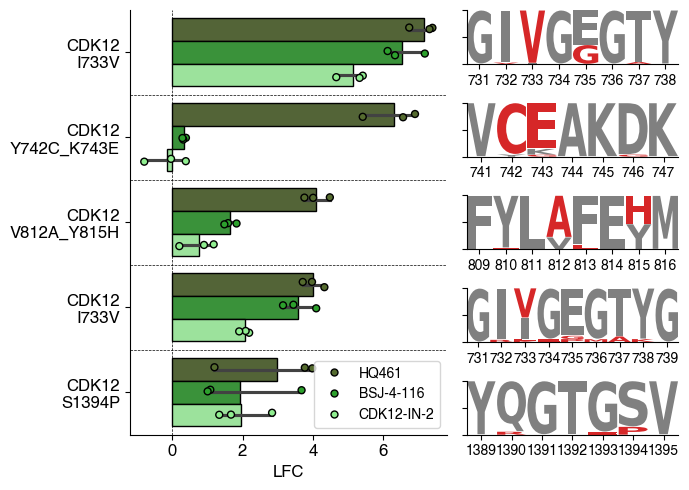

In [ ]:
from matplotlib import gridspec


fig = plt.figure(figsize=(7, 5))

num_to_plot = 5
gs = gridspec.GridSpec(num_to_plot, 2, width_ratios=[1.5, 1]) 

guides = list(subset[:num_to_plot]['gRNA_id'])


ax0 = plt.subplot(gs[:,0])

palette = ['darkolivegreen','tab:green', 'lightgreen']
hue_order = ['HQ461', 'BSJ-4-116', 'CDK12-IN-2']

sns.barplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id', order=guides, ax=ax0, linewidth=1, edgecolor='black', legend=False, hue_order=hue_order, palette=palette)
sns.stripplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id', order=guides, ax=ax0, dodge=True, linewidth=1, edgecolor='black', hue_order=hue_order, palette=palette)


top_hg = []
for i, val in enumerate(guides):
    merge = SAV_ABE2
    gRNA_id = val
    context_size=1
    min_perc = 2

    logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

    ax1 = plt.subplot(gs[i,1])
    
    ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
    ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
    ss_logo.ax.set_yticks([0,50,100])
    ss_logo.ax.set_yticklabels([], fontsize=10);
    #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
    #ss_logo.ax.set_ylabel('Probability', fontsize=14)

    ss_logo.ax.get_xticks()

    d_nonzero = d4[d4['%Reads']>0]


    for i, val in d_nonzero.iterrows():
        alt = val['alt']
        loc = val['codon']
        pp = val['%Reads']
        ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

    ss_logo.style_spines(spines=['right', 'top'], visible=False)

    subset2 = ABE2[(ABE2['gRNA_id']==gRNA_id) & (ABE2['HGVSp']!='WT') & (ABE2['%Reads']>=min_perc)]
    

    g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
    hg = list(subset2['HGVSp'])[0]
    top_hg.append(f'{g}\n{hg}')



ax0.set_yticklabels(top_hg)
ax0.tick_params(axis='both', which='major', labelsize=12)
ax0.set_ylabel('')
ax0.set_xlabel('LFC', fontsize=12)

for i in range(num_to_plot-1):
    ax0.axhline(i+0.5, linestyle='dashed', color='black', linewidth=0.5)


ax0.legend(loc='lower right')
ax0.axvline(0, linestyle='dashed', color='black', linewidth=0.5)
ax0.spines[['right', 'top']].set_visible(False)
fig.tight_layout()
#fig.savefig('../../figures/hq461_top_vars.pdf', transparent=True)

# ABE and CBE merge

In [458]:
data_ABE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_ABE_barcode_DMSO_base.csv')
data_CBE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_CBE_barcode_DMSO_base.csv')

condition = 'BSJ-4-116'
FDR_cutoff = 0.1

data_ABE = data_ABE.rename(columns = {f'LFC_median_ABE_{condition}':f'LFC_median_{condition}',f'FDR_ABE_{condition}': f'FDR_{condition}'})
data_CBE = data_CBE.rename(columns = {f'LFC_median_CBE_{condition}':f'LFC_median_{condition}', f'FDR_CBE_{condition}': f'FDR_{condition}'})

data_ABE['Editor']='ABE'
data_CBE['Editor'] = 'CBE'

data = pd.concat((data_ABE, data_CBE))


all_conditions = ['BSJ-4-116', 'CDK12-IN-2', 'HQ461']

subset = data[(data[f'FDR_{condition}']<FDR_cutoff) & (data['classification']=='targeting')].sort_values(by=f'LFC_median_{condition}', ascending=False)

subset['gRNA_id2'] = [f'{val["gRNA_id"]}_{val["Editor"]}' for i, val in subset.iterrows()]

In [425]:
topx

,gRNA_id,Gene,classification,ABE_BSJ-4-116_REP1,ABE_BSJ-4-116_REP2,ABE_BSJ-4-116_REP3,LFC_avg_ABE_BSJ-4-116,LFC_median_ABE_BSJ-4-116,base_RPM,base_RAW,...,LFC_avg_CBE_T0,LFC_median_CBE_T0,p_CBE_BSJ-4-116,FDR_CBE_BSJ-4-116,p_CBE_CDK12-IN-2,FDR_CBE_CDK12-IN-2,p_CBE_HQ461,p_CBE_T0,FDR_CBE_T0,gRNA_id2
0,gRNA_CDK12_targ_2232,CDK12,targeting,6.125533,6.335788,7.184101,6.548474,6.335788,73.276138,3369.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gRNA_CDK12_targ_2232_ABE
1,gRNA_CDK12_targ_3351,CDK12,targeting,NaN,NaN,NaN,NaN,NaN,41.689468,1363.0,...,1.158584,1.635614,1.836945e-03,0.351951,7.202656e-07,0.000877,4.102532e-10,0.113926,0.641774,gRNA_CDK12_targ_3351_CBE
2,gRNA_CDK12_targ_2238,CDK12,targeting,0.386960,0.288864,0.312813,0.329546,0.312813,29.924039,563.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gRNA_CDK12_targ_2238_ABE
3,gRNA_CDK12_targ_3395,CDK12,targeting,NaN,NaN,NaN,NaN,NaN,61.671464,1657.0,...,1.110857,1.406557,3.311692e-01,0.999995,5.338094e-01,0.971536,4.102532e-10,0.137709,0.683302,gRNA_CDK12_targ_3395_CBE
4,gRNA_CDK12_targ_3394,CDK12,targeting,NaN,NaN,NaN,NaN,NaN,5.173406,139.0,...,1.353074,1.308316,7.484682e-09,0.000036,1.669686e-08,0.000038,8.082480e-09,0.060805,0.501694,gRNA_CDK12_targ_3394_CBE
5,gRNA_CDK12_targ_3396,CDK12,targeting,NaN,NaN,NaN,NaN,NaN,55.851040,1826.0,...,0.388700,0.572441,4.473734e-01,0.999995,2.929773e-02,1.000000,8.082480e-09,0.579052,0.999993,gRNA_CDK12_targ_3396_CBE
6,gRNA_CDK13_targ_5767,CDK13,targeting,NaN,NaN,NaN,NaN,NaN,2.950841,90.0,...,2.097245,1.947008,4.832778e-03,0.454503,6.629044e-03,0.319507,7.068638e-05,0.004315,0.187559,gRNA_CDK13_targ_5767_CBE
7,gRNA_CDK12_targ_3392,CDK12,targeting,1.827192,1.586179,1.481560,1.631643,1.586179,25.178391,515.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gRNA_CDK12_targ_3392_ABE
8,gRNA_CDK12_targ_2233,CDK12,targeting,3.445245,3.149981,4.093716,3.562981,3.445245,57.824745,1889.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gRNA_CDK12_targ_2233_ABE
9,gRNA_CDK12_targ_3874,CDK12,targeting,3.677316,1.005323,1.080880,1.921173,1.080880,63.557104,1504.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gRNA_CDK12_targ_3874_ABE


In [459]:
topx = subset[:20].reset_index(drop=True)

conditions = ['HQ461', 'BSJ-4-116', 'CDK12-IN-2']
true_name = ['HQ461', 'BSJ-4-116', 'CDK12-IN-2']
condition_dict = dict(zip(conditions, true_name))

condition = []
replicate = []
lfc = []
g_id = []
g_id2 = []
names = []
editor = []

for i, val in topx.iterrows():

    g = val['gRNA_id']
    #nn = val['Gene'] + ' ' + val['Top_HGVSp'] #+ f'\n({val["gRNA_id"]})'
    editor1 = val['Editor']
    

    for drug in conditions:
        d = condition_dict[drug]

        for rep in range(1,4):

            #if (f'ABE_{drug}_REP{rep}' in topx.columns) or (f'CBE_{drug}_REP{rep}' in topx.columns):
                
            if editor1=='ABE':
    
                r = f'ABE_{drug}_REP{rep}'
                l = val[r]
                
            elif editor1=='CBE':
                r = f'CBE_{drug}_REP{rep}'
                l = val[r]
       

            lfc.append(l)
            condition.append(d)
            replicate.append(rep)
            g_id.append(g)
            g_id2.append(f'{g}_{editor1}')
            editor.append(editor1)
            #names.append(nn)

plot_df = pd.DataFrame(dict(zip(['gRNA_id', 'gRNA_id2', 'Replicate', 'LFC', 'Condition', 'Editor'], [g_id, g_id2, replicate, lfc, condition, editor]))).sort_values(by='LFC', ascending=False)

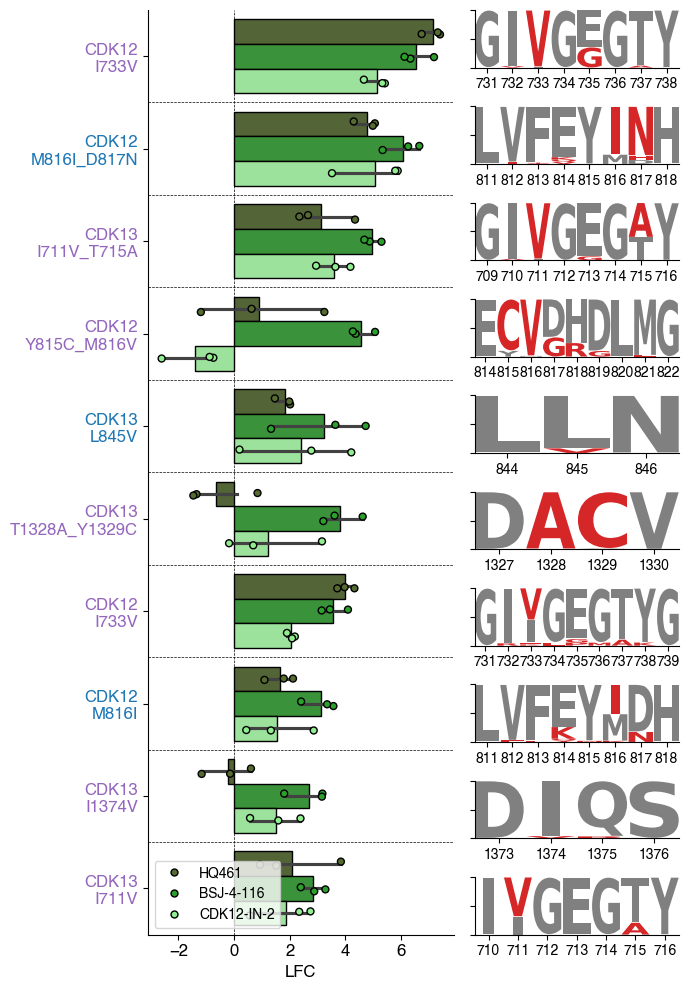

In [460]:
from matplotlib import gridspec


fig = plt.figure(figsize=(7, 10))

num_to_plot = 10
gs = gridspec.GridSpec(num_to_plot, 2, width_ratios=[1.5, 1]) 

guides = list(subset[:num_to_plot]['gRNA_id2'])
editors= list(subset[:num_to_plot]['Editor'])


ax0 = plt.subplot(gs[:,0])

palette = ['darkolivegreen','tab:green', 'lightgreen']
hue_order = ['HQ461', 'BSJ-4-116', 'CDK12-IN-2']

sns.barplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, linewidth=1, edgecolor='black', legend=False, hue_order=hue_order, palette=palette)
sns.stripplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, dodge=True, linewidth=1, edgecolor='black', hue_order=hue_order, palette=palette)


top_hg = []
for i, val in enumerate(guides):

    if editors[i]=='ABE':
        merge = SAV_ABE2
        gRNA_id = val[:-4]
        context_size=1
        min_perc = 2

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = ABE2[(ABE2['gRNA_id']==gRNA_id) & (ABE2['HGVSp']!='WT') & (ABE2['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        top_hg.append(f'{g}\n{hg}')

        
    elif editors[i]=='CBE':
        merge = SAV_CBE2
        gRNA_id = val[:-4]
        context_size=1
        min_perc = 2

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = CBE2[(CBE2['gRNA_id']==gRNA_id) & (CBE2['HGVSp']!='WT') & (CBE2['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        top_hg.append(f'{g}\n{hg}')



ax0.set_yticklabels(top_hg)

for i, tick_label in enumerate(ax0.axes.get_yticklabels()):
    if editors[i]=='ABE':
        tick_label.set_color("tab:purple")
    if editors[i]=='CBE':
        tick_label.set_color("tab:blue")
        
ax0.tick_params(axis='both', which='major', labelsize=12)
ax0.set_ylabel('')
ax0.set_xlabel('LFC', fontsize=12)

for i in range(num_to_plot-1):
    ax0.axhline(i+0.5, linestyle='dashed', color='black', linewidth=0.5)


ax0.legend(loc='lower left')
ax0.axvline(0, linestyle='dashed', color='black', linewidth=0.5)
ax0.spines[['right', 'top']].set_visible(False)
fig.tight_layout()

#fig.savefig('../../figures/bsj_top_vars.pdf', transparent=True)

# Subpool 1

In [453]:
data_ABE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/ABE_subpool1_barcode_DMSO_base.csv')
data_CBE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CBE_subpool1_barcode_DMSO_base.csv')


FDR_cutoff = 0.1
condition = 'KI-CDK9d-32N_5000nM'

data_ABE['Editor']='ABE'
data_CBE['Editor'] = 'CBE'

data = pd.concat((data_ABE, data_CBE))

all_conditions = ['KI-CDK9d-32_100nM', 'KI-CDK9d-32_1000nM', 'KI-CDK9d-32N_1250nM', 'KI-CDK9d-32N_5000nM', 'KB-0742_1500nM']

subset = data[(data[f'FDR_{condition}']<FDR_cutoff) & (data['classification']=='targeting')].sort_values(by=f'LFC_median_{condition}', ascending=False)

subset['gRNA_id2'] = [f'{val["gRNA_id"]}_{val["Editor"]}' for i, val in subset.iterrows()]



In [454]:
subset = subset[subset['Gene']=='CDK9']
topx = subset[:10].reset_index(drop=True)

conditions = ['KI-CDK9d-32_100nM', 'KI-CDK9d-32_1000nM', 'KI-CDK9d-32N_1250nM', 'KI-CDK9d-32N_5000nM', 'KB-0742_1500nM']
true_name  = ['KI-CDK9d-32 100nM', 'KI-CDK9d-32 1,000nM', 'KI-CDK9d-32N 1,250nM', 'KI-CDK9d-32N 5,000nM', 'KB-0742 1,500nM']

condition_dict = dict(zip(conditions, true_name))

condition = []
replicate = []
lfc = []
g_id = []
g_id2 = []
names = []
editor = []

for i, val in topx.iterrows():

    g = val['gRNA_id']
    #nn = val['Gene'] + ' ' + val['Top_HGVSp'] #+ f'\n({val["gRNA_id"]})'
    editor1 = val['Editor']
    

    for drug in conditions:
        d = condition_dict[drug]

        for rep in range(1,4):

            #if (f'ABE_{drug}_REP{rep}' in topx.columns) or (f'CBE_{drug}_REP{rep}' in topx.columns):
                
            if editor1=='ABE':
    
                r = f'{drug}_REP{rep}'
                l = val[r]
                
            elif editor1=='CBE':
                r = f'{drug}_REP{rep}'
                l = val[r]
       

            lfc.append(l)
            condition.append(d)
            replicate.append(rep)
            g_id.append(g)
            g_id2.append(f'{g}_{editor1}')
            editor.append(editor1)
            #names.append(nn)

plot_df = pd.DataFrame(dict(zip(['gRNA_id', 'gRNA_id2', 'Replicate', 'LFC', 'Condition', 'Editor'], [g_id, g_id2, replicate, lfc, condition, editor]))).sort_values(by='LFC', ascending=False)

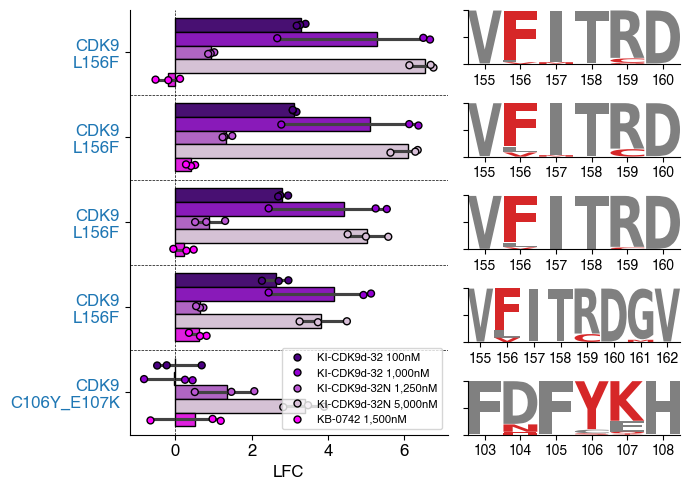

In [ ]:
from matplotlib import gridspec


fig = plt.figure(figsize=(7, 5))

num_to_plot = 5
gs = gridspec.GridSpec(num_to_plot, 2, width_ratios=[1.5, 1]) 

guides = list(subset[:num_to_plot]['gRNA_id2'])
editors= list(subset[:num_to_plot]['Editor'])


ax0 = plt.subplot(gs[:,0])

palette = ['darkolivegreen','tab:green', 'lightgreen']
palette = ['indigo', 'darkviolet', 'mediumorchid', 'thistle', 'magenta']
hue_order = ['KI-CDK9d-32 100nM', 'KI-CDK9d-32 1,000nM', 'KI-CDK9d-32N 1,250nM', 'KI-CDK9d-32N 5,000nM', 'KB-0742 1,500nM']

sns.barplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, linewidth=1, edgecolor='black', legend=False, hue_order=hue_order, palette=palette)
sns.stripplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, dodge=True, linewidth=1, edgecolor='black', hue_order=hue_order, palette=palette)


top_hg = []
for i, val in enumerate(guides):

    if editors[i]=='ABE':
        merge = SAV_ABE1
        gRNA_id = val[:-4]
        context_size=1
        min_perc = 2

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = ABE1[(ABE1['gRNA_id']==gRNA_id) & (ABE1['HGVSp']!='WT') & (ABE1['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        top_hg.append(f'{g}\n{hg}')

        
    elif editors[i]=='CBE':
        merge = SAV_CBE1
        gRNA_id = val[:-4]
        context_size=1
        min_perc = 2

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = CBE1[(CBE1['gRNA_id']==gRNA_id) & (CBE1['HGVSp']!='WT') & (CBE1['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        top_hg.append(f'{g}\n{hg}')



ax0.set_yticklabels(top_hg)

for i, tick_label in enumerate(ax0.axes.get_yticklabels()):
    if editors[i]=='ABE':
        tick_label.set_color("tab:purple")
    if editors[i]=='CBE':
        tick_label.set_color("tab:blue")
        
ax0.tick_params(axis='both', which='major', labelsize=12)
ax0.set_ylabel('')
ax0.set_xlabel('LFC', fontsize=12)

for i in range(num_to_plot-1):
    ax0.axhline(i+0.5, linestyle='dashed', color='black', linewidth=0.5)


ax0.legend(loc='lower right', fontsize=8)
ax0.axvline(0, linestyle='dashed', color='black', linewidth=0.5)
ax0.spines[['right', 'top']].set_visible(False)
fig.tight_layout()
#fig.savefig('../../figures/cdk9_top_vars.pdf', transparent=True)

In [433]:
plot_df

,gRNA_id,gRNA_id2,Replicate,LFC,Condition,Editor
11,gRNA_CDK9_targ_1200,gRNA_CDK9_targ_1200_CBE,3,6.758645,"KI-CDK9d-32N 5,000nM",CBE
10,gRNA_CDK9_targ_1200,gRNA_CDK9_targ_1200_CBE,2,6.686852,"KI-CDK9d-32N 5,000nM",CBE
3,gRNA_CDK9_targ_1200,gRNA_CDK9_targ_1200_CBE,1,6.668399,"KI-CDK9d-32 1,000nM",CBE
4,gRNA_CDK9_targ_1200,gRNA_CDK9_targ_1200_CBE,2,6.493467,"KI-CDK9d-32 1,000nM",CBE
19,gRNA_CDK9_targ_1199,gRNA_CDK9_targ_1199_CBE,2,6.365646,"KI-CDK9d-32 1,000nM",CBE
...,...,...,...,...,...,...
103,gRNA_CDK9_targ_1468,gRNA_CDK9_targ_1468_ABE,2,-1.437810,"KB-0742 1,500nM",ABE
88,gRNA_CDK19_targ_6713,gRNA_CDK19_targ_6713_ABE,2,-1.473799,"KB-0742 1,500nM",ABE
144,gRNA_CDK9_targ_1210,gRNA_CDK9_targ_1210_ABE,1,-1.654135,"KI-CDK9d-32N 5,000nM",ABE
99,gRNA_CDK9_targ_1468,gRNA_CDK9_targ_1468_ABE,1,-2.099948,"KI-CDK9d-32N 5,000nM",ABE


# Subpool 3

In [ ]:
data_ABE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK2_4_6_ABE_barcode_DMSO_base.csv')
data_CBE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK2_4_6_CBE_barcode_DMSO_base.csv')

condition = 'ATIRMO'
condition_a = condition

FDR_cutoff = 0.1
base_min = 100
max_WT = 90

data_ABE = data_ABE.rename(columns = {f'LFC_median_ABE_{condition}':f'LFC_median_{condition}',f'FDR_ABE_{condition}': f'FDR_{condition}'})
data_CBE = data_CBE.rename(columns = {f'LFC_median_CBE_{condition}':f'LFC_median_{condition}', f'FDR_CBE_{condition}': f'FDR_{condition}'})

data_ABE['Editor']='ABE'
data_CBE['Editor'] = 'CBE'

WT_ABE = SAV_ABE3[SAV_ABE3['HGVSp']=='WT'].reset_index(drop=True)
WT_CBE = SAV_CBE3[SAV_CBE3['HGVSp']=='WT'].reset_index(drop=True)
WT_ABE = WT_ABE[['gRNA_id', '%Reads']].rename(columns = {'%Reads':'WT_perc'})
WT_CBE = WT_CBE[['gRNA_id', '%Reads']].rename(columns = {'%Reads':'WT_perc'})

data_ABE = pd.merge(data_ABE, WT_ABE, on='gRNA_id')
data_CBE = pd.merge(data_CBE, WT_CBE, on='gRNA_id')

data = pd.concat((data_ABE, data_CBE))

all_conditions = ['RIBO', 'ABEMA', 'ATIRMO', 'PALBO', 'TAGTO', 'INX']

subset = data[(data[f'FDR_{condition}']<FDR_cutoff) & (data['classification']=='targeting') & (data['base_RAW']>=base_min) & (data['WT_perc']<=90)].sort_values(by=f'LFC_median_{condition}', ascending=False)

subset['gRNA_id2'] = [f'{val["gRNA_id"]}_{val["Editor"]}' for i, val in subset.iterrows()]

In [529]:
topx = subset[:20].reset_index(drop=True)

conditions = ['RIBO', 'ABEMA', 'ATIRMO', 'PALBO', 'TAGTO', 'INX']
true_name = ['Ribociclib', 'Abemaciclib', 'Atirmociclib', 'Palbociclib', 'Tagtociclib', 'INX-315']
condition_dict = dict(zip(conditions, true_name))

condition = []
replicate = []
lfc = []
g_id = []
g_id2 = []
names = []
editor = []

for i, val in topx.iterrows():

    g = val['gRNA_id']
    #nn = val['Gene'] + ' ' + val['Top_HGVSp'] #+ f'\n({val["gRNA_id"]})'
    editor1 = val['Editor']
    

    for drug in conditions:
        d = condition_dict[drug]

        for rep in range(1,4):

            #if (f'ABE_{drug}_REP{rep}' in topx.columns) or (f'CBE_{drug}_REP{rep}' in topx.columns):
                
            if editor1=='ABE':
    
                r = f'ABE_{drug}_REP{rep}'
                l = val[r]
                
            elif editor1=='CBE':
                r = f'CBE_{drug}_REP{rep}'
                l = val[r]
       

            lfc.append(l)
            condition.append(d)
            replicate.append(rep)
            g_id.append(g)
            g_id2.append(f'{g}_{editor1}')
            editor.append(editor1)
            #names.append(nn)

plot_df = pd.DataFrame(dict(zip(['gRNA_id', 'gRNA_id2', 'Replicate', 'LFC', 'Condition', 'Editor'], [g_id, g_id2, replicate, lfc, condition, editor]))).sort_values(by='LFC', ascending=False)

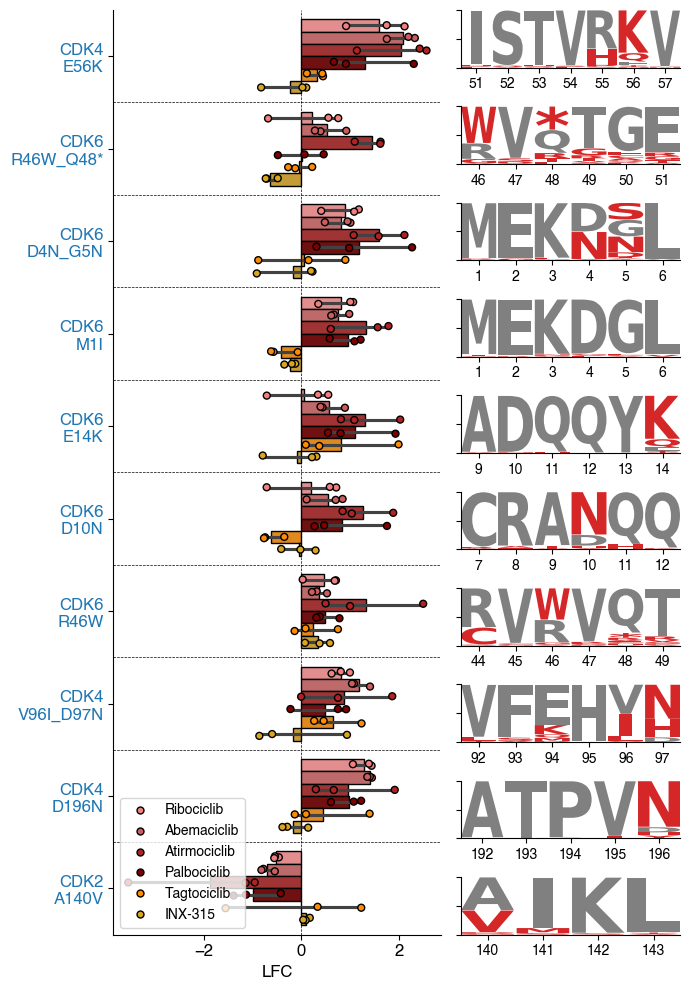

In [534]:
from matplotlib import gridspec


fig = plt.figure(figsize=(7, 10))

num_to_plot = 10
gs = gridspec.GridSpec(num_to_plot, 2, width_ratios=[1.5, 1]) 

guides = list(subset[:num_to_plot]['gRNA_id2'])
editors= list(subset[:num_to_plot]['Editor'])


ax0 = plt.subplot(gs[:,0])

palette = ['lightcoral', 'indianred', 'firebrick', 'maroon', 'darkorange', 'goldenrod']
hue_order = ['Ribociclib', 'Abemaciclib', 'Atirmociclib', 'Palbociclib', 'Tagtociclib', 'INX-315']

sns.barplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, linewidth=1, edgecolor='black', legend=False, hue_order=hue_order, palette=palette)
sns.stripplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, dodge=True, linewidth=1, edgecolor='black', hue_order=hue_order, palette=palette)


top_hg = []
for i, val in enumerate(guides):

    if editors[i]=='ABE':
        merge = SAV_ABE3
        gRNA_id = val[:-4]
        context_size=0
        min_perc = 1

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = ABE3[(ABE3['gRNA_id']==gRNA_id) & (ABE3['HGVSp']!='WT') & (ABE3['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        top_hg.append(f'{g}\n{hg}')

        
    elif editors[i]=='CBE':
        merge = SAV_CBE3
        gRNA_id = val[:-4]
        context_size=0
        min_perc = 1

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = CBE3[(CBE3['gRNA_id']==gRNA_id) & (CBE3['HGVSp']!='WT') & (CBE3['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        top_hg.append(f'{g}\n{hg}')



ax0.set_yticklabels(top_hg)

for i, tick_label in enumerate(ax0.axes.get_yticklabels()):
    if editors[i]=='ABE':
        tick_label.set_color("tab:purple")
    if editors[i]=='CBE':
        tick_label.set_color("tab:blue")
        
ax0.tick_params(axis='both', which='major', labelsize=12)
ax0.set_ylabel('')
ax0.set_xlabel('LFC', fontsize=12)

for i in range(num_to_plot-1):
    ax0.axhline(i+0.5, linestyle='dashed', color='black', linewidth=0.5)


ax0.legend(loc='lower left')
ax0.axvline(0, linestyle='dashed', color='black', linewidth=0.5)
ax0.spines[['right', 'top']].set_visible(False)
fig.tight_layout()

fig.savefig(f'../../figures/{condition_a}_top_vars.pdf', transparent=True)

In [533]:
np.unique(SAV_CBE3[SAV_CBE3['gRNA_id']=='gRNA_CDK6_targ_8215']['Codon'])

array(['1', '2', '3', '4', '5', '6', 'WT'], dtype=object)

# version with DNA? too much?

In [182]:
fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(4, 2, width_ratios=[3, 1]) 
gs[0]

GridSpec(4, 2, width_ratios=[3, 1])[0:1, 0:1]

<Figure size 1200x600 with 0 Axes>